<a href="https://colab.research.google.com/github/diwakaraditya/forecast-project/blob/main/forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib scikit-learn statsmodels prophet xgboost tensorflow


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Forecasting Case- Study.xlsx to Forecasting Case- Study.xlsx


First 5 rows:
        State                 Date        Total   Category
0     Alabama  2019-01-12 00:00:00  109574036.0  Beverages
1     Arizona  2019-01-12 00:00:00  109101594.6  Beverages
2    Arkansas  2019-01-12 00:00:00   58049432.2  Beverages
3  California  2019-01-12 00:00:00  444766890.6  Beverages
4    Colorado  2019-01-12 00:00:00   89816716.3  Beverages

Missing values:
State       0
Date        0
Total       0
Category    0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 8084 entries, 0 to 3183
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   State     8084 non-null   object        
 1   Date      8084 non-null   datetime64[ns]
 2   Total     8084 non-null   float64       
 3   Category  8084 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 315.8+ KB
None


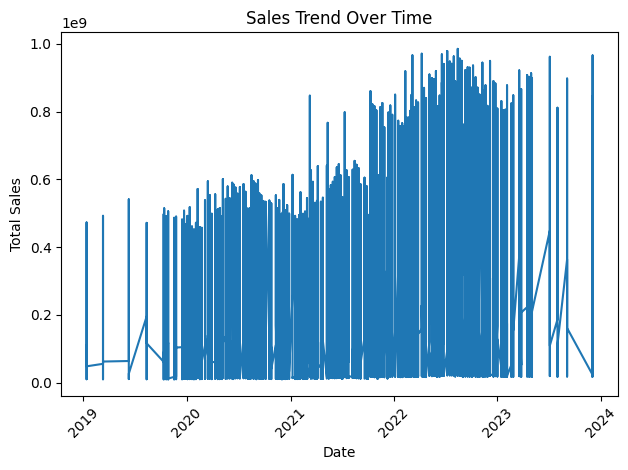

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_excel("Forecasting Case- Study.xlsx")

# 2. Show first rows
print("First 5 rows:")
print(df.head())

# 3. Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# 4. Sort by Date
df = df.sort_values(by='Date')

# 5. Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# 6. Handle missing values
df = df.ffill()

# 7. Dataset info
print("\nDataset Info:")
print(df.info())

# 8. Plot sales trend
plt.figure()
plt.plot(df['Date'], df['Total'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Load dataset
df = pd.read_excel("Forecasting Case- Study.xlsx")

# 2. Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# 3. Sort by Date
df = df.sort_values(by='Date')

# 4. Handle Missing Values

# Option 1: Forward Fill
df = df.ffill()

# Option 2 (better): Interpolation (uncomment if needed)
# df['Total'] = df['Total'].interpolate()

# 5. Set Date as Index
df.set_index('Date', inplace=True)

print("After setting Date as index:")
print(df.head())

# 6. State-wise data separation

state_groups = {}
for state in df['State'].unique():
    state_groups[state] = df[df['State'] == state]

# Example: Access Maharashtra data
print("\nSample Maharashtra Data:")
print(state_groups[list(state_groups.keys())[0]].head())


After setting Date as index:
                     State        Total   Category
Date                                              
2019-01-12         Alabama  109574036.0  Beverages
2019-01-12      New Mexico   34731555.3  Beverages
2019-01-12        New York  240815212.2  Beverages
2019-01-12  North Carolina  182341458.0  Beverages
2019-01-12            Ohio  194452564.4  Beverages

Sample Maharashtra Data:
              State        Total   Category
Date                                       
2019-01-12  Alabama  109574036.0  Beverages
2019-03-11  Alabama  112189103.8  Beverages
2019-06-10  Alabama  129106730.4  Beverages
2019-08-12  Alabama  108083723.8  Beverages
2019-10-11  Alabama  110932912.8  Beverages


In [ ]:
import pandas as pd

# 1. Load dataset
df = pd.read_excel("Forecasting Case- Study.xlsx")

# 2. Clean + prepare
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# Missing values handle
df = df.ffill()

# 3. Feature Engineering (IMPORTANT 🔥)

# Lag features
df['lag_1'] = df['Total'].shift(1)
df['lag_7'] = df['Total'].shift(7)

# Rolling mean
df['rolling_mean_7'] = df['Total'].rolling(window=7).mean()

# Date-based features
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek

# 4. Drop NaN (due to lag/rolling)
df = df.dropna()

print("Feature engineered data:")
print(df.head())

Feature engineered data:
             State       Date        Total   Category        lag_1  \
30    Pennsylvania 2019-01-12  197064569.3  Beverages   58257574.4   
32  South Carolina 2019-01-12   97713917.2  Beverages  197064569.3   
23   New Hampshire 2019-01-12   30014723.1  Beverages   97713917.2   
33    South Dakota 2019-01-12   14701327.2  Beverages   30014723.1   
35           Texas 2019-01-12  472848726.3  Beverages   14701327.2   

          lag_7  rolling_mean_7  month  day_of_week  
30  109574036.0    1.407723e+08      1            5  
32   34731555.3    1.497698e+08      1            5  
23  240815212.2    1.196554e+08      1            5  
33  182341458.0    9.570682e+07      1            5  
35  194452564.4    1.354777e+08      1            5  


In [ ]:
# Make sure Date is index (IMPORTANT)
df.set_index('Date', inplace=True)

# Train-Test Split (Chronological)
train = df[:'2023']
test = df['2024':]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


Train Shape: (8077, 8)
Test Shape: (0, 8)


In [ ]:
print(df.index.min())
print(df.index.max())


2019-01-12 00:00:00
2023-12-03 00:00:00


In [ ]:
split_date = df.index.max() - pd.DateOffset(months=3)

train = df[df.index < split_date]
test = df[df.index >= split_date]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (7948, 8)
Test Shape: (129, 8)


MAE: 110721951.9643411


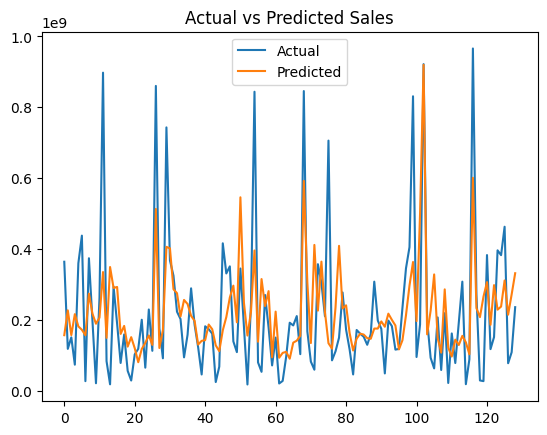

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# 1. Features & Target
features = ['lag_1', 'lag_7', 'rolling_mean_7', 'month', 'day_of_week']
target = 'Total'

# 2. Train-Test Split (use previous step result)
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# 3. Model
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

# 4. Train
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. Evaluation
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# 7. Plot Actual vs Predicted
plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 1. Target column
series = train['Total']

# 2. Build ARIMA model
model = ARIMA(series, order=(5,1,0))

# 3. Train model
model_fit = model.fit()

# 4. Summary
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Total   No. Observations:                 7948
Model:                 ARIMA(5, 1, 0)   Log Likelihood             -161761.018
Date:                Wed, 06 May 2026   AIC                         323534.035
Time:                        19:13:23   BIC                         323575.919
Sample:                             0   HQIC                        323548.376
                               - 7948                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8064      0.012    -69.899      0.000      -0.829      -0.784
ar.L2         -0.7514      0.014    -53.819      0.000      -0.779      -0.724
ar.L3         -0.4094      0.016    -25.543      0.0

In [ ]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare data for Prophet
prophet_df = train.reset_index()[['Date', 'Total']]


prophet_df = prophet_df.rename(columns={
    'Date': 'ds',
    'Total': 'y'
})

print(prophet_df.head())

# 2. Model
model = Prophet()

# 3. Train
model.fit(prophet_df)

          ds            y
0 2019-01-12  197064569.3
1 2019-01-12   97713917.2
2 2019-01-12   30014723.1
3 2019-01-12   14701327.2
4 2019-01-12  472848726.3


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAE: 109589685.2635659


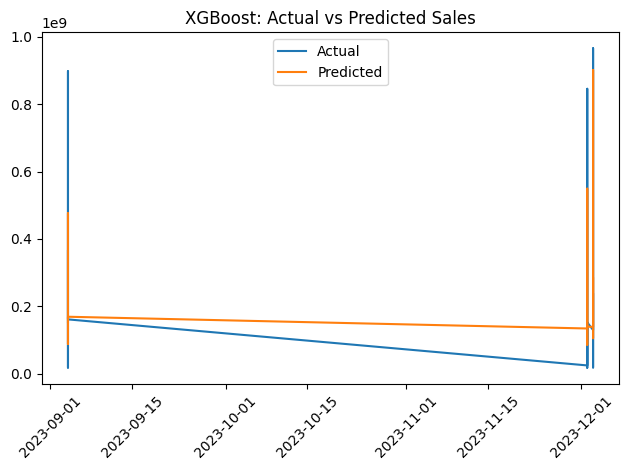

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt


features = ['lag_1', 'lag_7', 'rolling_mean_7', 'month', 'day_of_week']
target = 'Total'


X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]


model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)


model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# Plot Actual vs Predicted
plt.figure()
plt.plot(test.index, y_test.values, label='Actual')
plt.plot(test.index, y_pred, label='Predicted')
plt.legend()
plt.title("XGBoost: Actual vs Predicted Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [ ]:

data = df[['Total']].values

# Scale data (VERY IMPORTANT for LSTM)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

seq_length = 7   # last 7 days
X, y = create_sequences(data_scaled, seq_length)

print("Shape of X:", X.shape)  # (samples, 7, 1)

Shape of X: (8070, 7, 1)


In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=16)

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0242
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0235
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0234
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0234
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0234
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0232
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0231
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0229
Epoch 9/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0228
Epoch 10/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0227


In [ ]:
y_pred = model.predict(X_test)

# Inverse scale
y_pred = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


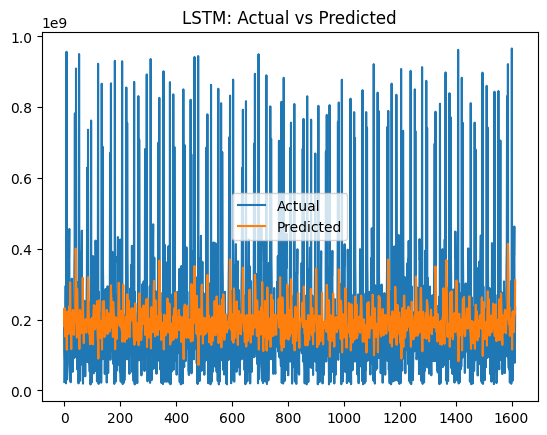

In [ ]:
plt.figure()
plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("LSTM: Actual vs Predicted")
plt.show()

In [ ]:
# ARIMA Forecast (IMPORTANT)
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Train model
model = ARIMA(train['Total'], order=(5,1,0))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [ ]:
arima_forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
from prophet import Prophet

prophet_model = Prophet()
prophet_model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = prophet_model.make_future_dataframe(periods=len(test))

In [ ]:
prophet_forecast = prophet_model.predict(future)

In [ ]:
prophet_pred = prophet_forecast['yhat'][-len(test):].values

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_prophet = mean_absolute_error(test['Total'], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test['Total'], prophet_pred))

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

Prophet MAE: 137113806.71839923
Prophet RMSE: 204089730.0059869


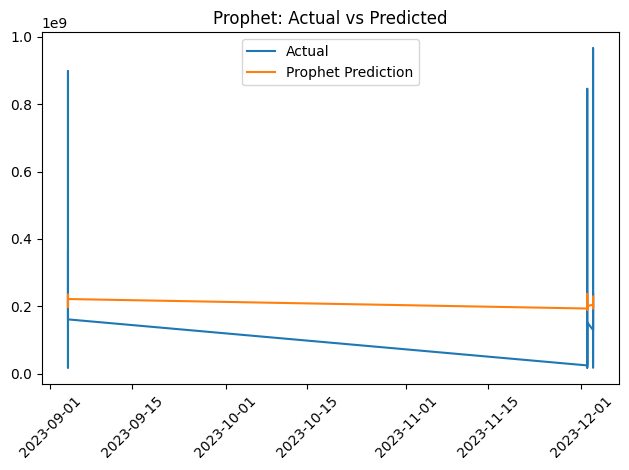

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(test.index, test['Total'], label='Actual')
plt.plot(test.index, prophet_pred, label='Prophet Prediction')
plt.legend()
plt.title("Prophet: Actual vs Predicted")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(X.shape[1], 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_train, y_train, epochs=10, batch_size=16)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0243
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0235
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0233
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0232
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0232
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0230
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0229
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0228
Epoch 9/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0227
Epoch 10/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0226


In [ ]:
y_pred_lstm = lstm_model.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


In [ ]:
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_actual = scaler.inverse_transform(y_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ---- XGBoost ----
mae_xgb = mean_absolute_error(y_test, y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))

# ---- ARIMA ----
mae_arima = mean_absolute_error(test['Total'], arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test['Total'], arima_forecast))

# ---- Prophet ----
mae_prophet = mean_absolute_error(test['Total'], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test['Total'], prophet_pred))

# ---- LSTM ----
mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))

# ---- Final Table ----
results = pd.DataFrame({
    'Model': ['XGBoost', 'ARIMA', 'Prophet', 'LSTM'],
    'MAE': [mae_xgb, mae_arima, mae_prophet, mae_lstm],
    'RMSE': [rmse_xgb, rmse_arima, rmse_prophet, rmse_lstm]
})

print("\nFinal Model Comparison:")
print(results)


Final Model Comparison:
     Model           MAE          RMSE
0  XGBoost  1.977916e+08  2.024376e+08
1    ARIMA  1.305609e+08  2.149317e+08
2  Prophet  1.371138e+08  2.040897e+08
3     LSTM  1.252904e+08  1.961756e+08


In [ ]:
best_model = results.loc[results['MAE'].idxmin()]
print(best_model)

Model                LSTM
MAE      125290360.550805
RMSE     196175559.481034
Name: 3, dtype: object


In [ ]:
best_model_name = best_model['Model']
print(best_model_name)

LSTM


In [ ]:
import pickle

if best_model_name == 'XGBoost':
    pickle.dump(model, open('model.pkl', 'wb'))

elif best_model_name == 'ARIMA':
    pickle.dump(model_fit, open('model.pkl', 'wb'))

elif best_model_name == 'Prophet':
    pickle.dump(prophet_model, open('model.pkl', 'wb'))

elif best_model_name == 'LSTM':
    lstm_model.save("model.h5")

In [ ]:
from google.colab import files
files.download('model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>